## **2. Exploring Data Analysis (EDA)** <a name="eda"></a>

In [ ]:
import pandas as pd
import numpy as np
import json
from itertools import combinations
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestRegressor
import networkx as nx  
from matplotlib.lines import Line2D
from networkx.algorithms import community
import matplotlib.patches as mpatches

In [ ]:
file_path = "manga.json"

### **a. Overall Data View** <a name="overall"></a>

In [ ]:
df = pd.read_json(file_path)

In [ ]:
df.head()

In [ ]:
rows, cols = df.shape
print(f'Number of rows: {rows}')
print(f'Number of cols: {cols}')

### **b. Column Detail** <a name="column"></a>

In [ ]:
descriptions = pd.read_csv('desc.csv')

pd.set_option('display.max_colwidth', None)
descriptions

### **C. Distribution Value** <a name="distribution"></a>

**Data Cleaning**

In [ ]:
# Calculate missing values count and ratio
missing_values = df.isnull().sum()
missing_ratio = (missing_values / len(df)) * 100

# Filter out columns with zero missing values
missing_table = pd.DataFrame({
    'Column': missing_values[missing_values > 0].index,
    'Missing Count': missing_values[missing_values > 0].values,
    'Missing Ratio (%)': missing_ratio[missing_values > 0].values
}).sort_values(by='Missing Count', ascending=False)

# Print the table
print(missing_table)

In [ ]:
# Drop hentai genre
filtered_df = df[~df['genres'].apply(
    lambda x: any(genre.get('name') == 'Hentai' for genre in x) if isinstance(x, list) else False
)]

# Drop english title column
filtered_df = filtered_df.drop(columns=['title_english'])
filtered_df = filtered_df.drop(columns=['title_japanese']) 
# Add on_goning column
filtered_df['on_going'] = filtered_df['status'].str.contains('Publishing', na=False)    

# Fill volumes and chapters missing values with 0
filtered_df['volumes'] = filtered_df['volumes'].fillna(0)
filtered_df['chapters'] = filtered_df['chapters'].fillna(0)
# synopsis = null => "No synopsis available"
filtered_df['synopsis'] = filtered_df['synopsis'].fillna(" ")

# Drop scroe_by, scrorded, backfround column
filtered_df = filtered_df.drop(columns=['scored_by'])
filtered_df = filtered_df.drop(columns=['scored'])
filtered_df = filtered_df.drop(columns=['background'])

# drop where rasnk is null
#filtered_df = filtered_df[filtered_df['rank'].notna()]

# Drop score is null
filtered_df = filtered_df[filtered_df['score'].notna()]
df=filtered_df
df.to_csv('cleaned_data.csv', index=False)


In [ ]:
print(df.shape)
#print the missing values after cleaning
missing_values_after = df.isnull().sum()
print("\nMissing values after cleaning:")
# Calculate missing values count and ratio
missing_values = df.isnull().sum()
missing_ratio = (missing_values / len(df)) * 100

# Filter out columns with zero missing values
missing_table = pd.DataFrame({
    'Column': missing_values.index,
    'Missing Count': missing_values.values,
    'Missing Ratio (%)': missing_ratio.values
}).sort_values(by='Missing Count', ascending=False)

# Print the table
print(missing_table)


In [ ]:
numerical_features = ['score', 'members', 'chapters', 'volumes', 'favorites']
print(df[numerical_features].describe().transpose())

In [ ]:

sns.histplot(df['score'], kde=True, bins=20, color='#3498db') # Using a different shade of blue
plt.title('Manga Score Distribution')
plt.xlabel('Score')
plt.ylabel('Frequency')
plt.axvline(df['score'].mean(), color='red', linestyle='--', label=f'Mean: {df["score"].mean():.2f}')

The data follows a very clean Normal Distribution centered around a mean of approximately 6.9 to 7.0.

In [ ]:
# Top 15 most popular genres
all_genres = [genre['name'] for genres_list in df['genres'] for genre in genres_list]
genre_counts = Counter(all_genres)
top_15_genres = genre_counts.most_common(15)
genres, counts = zip(*top_15_genres)
plt.figure(figsize=(12, 6))
sns.barplot(x=list(counts), y=list(genres), hue=list(genres), palette='viridis', legend=False)
plt.title('Top 15 Most Popular Genres')
plt.show()


In [ ]:
#get authors list for eacch manga from authors column
df['authors'] = df['authors'].apply(lambda authors: [author['name'] for author in authors] if isinstance(authors, list) else [])
df['genre_names'] = df['genres'].apply(lambda genres: [genre['name'] for genre in genres] if isinstance(genres, list) else [])

In [ ]:
# Remove this networkX + community detection section (Have not finished debugging)
# For future commits, please update in /myanimelist-data-collector/semantic_analysis/EDA_Analyse.ipynb
"""
top_manga = df.sort_values(by='popularity_score', ascending=False).head(60).copy()
G = nx.Graph()

# Coloring
COLOR_MANGA = '#75bfec'   # Sky blue
COLOR_GENRE = '#ffff00'   # Yellow
COLOR_AUTHOR = '#ff0000'  # Red

# 2. Node and edge creation (using top_manga)
for idx, row in top_manga.iterrows():
    manga_node = row['title'] # Simplified name for better label visibility
    G.add_node(manga_node, node_type='manga', size= 2000, color=COLOR_MANGA)
    
    if isinstance(row['genre_names'], list):
        for genre in row['genre_names']:
            G.add_node(genre, node_type='genre', size=1000, color=COLOR_GENRE)
            G.add_edge(manga_name, genre, relation='belongs_to_genre', weight=1)
            
    if isinstance(row['authors'], list):
        for author in row['authors']:
            auth_name = author['name'] if isinstance(author, dict) else str(author)
            
            # Get shorten names (first name only)
            short_auth = auth_name.split(',')[0] 
            G.add_node(short_auth, type='Author', size=1000, color=COLOR_AUTHOR)
            G.add_edge(manga_name, short_auth, relation='written_by', weight=2)

# Community Detection
communities = community.greedy_modularity_communities(G)

# Label communities for each node
node_community = {}
for i, comm in enumerate(communities):
    for node in comm:
        node_community[node] = i

# Visualization
plt.figure(figsize=(20, 15))
pos = nx.spring_layout(G, k=0.6, iterations=60, seed=42)

# Manga (Circle)
nx.draw_networkx_nodes(G, pos, 
                       nodelist=[n for n, d in G.nodes(data=True) if d['type'] == 'Manga'],
                       node_color=COLOR_MANGA, node_size=1200, node_shape='o', alpha=0.9, label='Manga')

# Genre (Square)
nx.draw_networkx_nodes(G, pos, 
                       nodelist=[n for n, d in G.nodes(data=True) if d['type'] == 'Genre'],
                       node_color=COLOR_GENRE, node_size=800, node_shape='s', alpha=0.8, label='Genre')

# Author (Triangle)
nx.draw_networkx_nodes(G, pos, 
                       nodelist=[n for n, d in G.nodes(data=True) if d['type'] == 'Author'],
                       node_color=COLOR_AUTHOR, node_size=800, node_shape='^', alpha=0.8, label='Author')

# Edges
# Manga-Genre (Solid line)
genre_edges = [(u, v) for u, v, d in G.edges(data=True) if d['relation'] == 'belongs_to_genre']
nx.draw_networkx_edges(G, pos, edgelist=genre_edges, width=1.0, edge_color='#bdc3c7', style='solid')

# Manga-Author (Dashed line)
author_edges = [(u, v) for u, v, d in G.edges(data=True) if d['relation'] == 'written_by']
nx.draw_networkx_edges(G, pos, edgelist=author_edges, width=1.5, edge_color='#7f8c8d', style='dashed')

# Labels
# Manga belongs to genre
labels = {n: n for n, d in G.nodes(data=True) if d['type'] in ['Manga', 'Genre', 'Author']}
nx.draw_networkx_labels(G, pos, labels, font_size=8, font_family='sans-serif', font_weight='bold')

# Legends
legend_elements = [
    mpatches.Patch(color=COLOR_MANGA, label='Manga (Node)'),
    mpatches.Patch(color=COLOR_GENRE, label='Genre (Node)'),
    mpatches.Patch(color=COLOR_AUTHOR, label='Author (Node)'),
    plt.Line2D([0], [0], color='#bdc3c7', lw=2, linestyle='solid', label='Relationship: Thuộc thể loại'),
    plt.Line2D([0], [0], color='#7f8c8d', lw=2, linestyle='dashed', label='Relationship: Được viết bởi')
]
plt.legend(handles=legend_elements, loc='upper right', fontsize=12)

plt.title("Knowledge Graph: Manga - Genre - Author Relationships\n(Top 60 Popular Manga)", fontsize=20)
plt.axis('off') 
plt.tight_layout()
plt.show()
"""

In [ ]:
# Hierarchical tree 
# 1. Prepare your data (adjust 'popularity_score' to your actual column name, e.g., 'score')
# We use .copy() to avoid SettingWithCopy warnings
top_manga_tree = df.nlargest(10, 'score').copy() 

G = nx.Graph()

# --- Level 0: Root ---
root_node = "Manga Database"
G.add_node(root_node, layer=0, label="Manga") 

# 2. Build the hierarchy
for _, row in top_manga_tree.iterrows():
    title = row['title']
    
    # Extract Genres (handle lists or empty values)
    genres = row['genre_names'] if isinstance(row['genre_names'], list) else ["General"]
    
    # Extract Authors (handle lists or empty values)
    authors = row['authors'] if isinstance(row['authors'], list) else ["Unknown Author"]
    # If the author is a dict or string with commas, we clean it
    author_list = [a['name'] if isinstance(a, dict) else str(a).split(',')[0] for a in authors]

    for genre in genres:
        # Level 1: Genre
        if not G.has_node(genre):
            G.add_node(genre, layer=1, label=genre)
        G.add_edge(root_node, genre)
        
        for author in author_list:
            # Level 2: Author (Unique ID to prevent different genres merging the same author)
            author_id = f"{genre}_{author}" 
            if not G.has_node(author_id):
                G.add_node(author_id, layer=2, label=author)
            G.add_edge(genre, author_id)
            
            # Level 3: Title
            # Note: If a manga has multiple genres/authors, it will appear under each branch
            title_id = f"{author_id}_{title}" 
            G.add_node(title_id, layer=3, label=title)
            G.add_edge(author_id, title_id)

# 3. Visualization Settings
plt.figure(figsize=(20, 10))
pos = nx.multipartite_layout(G, subset_key="layer")

# Color mapping by layer
colors = {0: '#008000', 1: '#ffff00', 2: '#ff4d4d', 3: '#75bfec'}
node_colors = [colors[G.nodes[n]['layer']] for n in G.nodes()]

# Draw the nodes and edges
nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=3000, alpha=0.8)
nx.draw_networkx_edges(G, pos, edge_color='silver', alpha=0.5, style='dashed')

# Add Labels with background boxes for readability
labels = nx.get_node_attributes(G, 'label')
for node, (x, y) in pos.items():
    layer = G.nodes[node]['layer']
    font_size = 10 if layer < 3 else 8
    plt.text(x, y, labels[node], fontsize=font_size, ha='center', va='center', 
             fontweight='bold', bbox=dict(facecolor='white', alpha=0.6, edgecolor='none'))

plt.title('Hierarchical View: Manga Discovery Tree', fontsize=18)
plt.axis('off')
plt.show()

### **D. Data Preprocessing** <a name="distribution"></a>

### Clean synopsis

In [ ]:
# Using google collab to run this section
"""
import pandas as pd
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tag import pos_tag
"""

In [ ]:
"""
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')
nltk.download('averaged_perceptron_tagger')
nltk.download('averaged_perceptron_tagger_eng')

custom_anime_stopwords = {
    'anime', 'manga', 'series', 'story', 'film', 'adaptation', 
    'written', 'illustrated', 'published', 'directed', 'season',
    'episode', 'character', 'plot', 'theme', 'source'
}

stop_words = set(stopwords.words('english')).union(custom_anime_stopwords)
lemmatizer = WordNetLemmatizer()
"""

In [ ]:
"""
def nltk_process_text(text):
    if not isinstance(text, str) or text.strip() == "":
        return ""
    
    # CLean text
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)
    
    # Tokenization, remove Stopwords & Lemmatization
    # Split text into words
    words = text.split()
    tagged_words = pos_tag(words)
    
    clean_words = []
    
    # Keep nouns and adjectives
    valid_tags = {'NN', 'NNS', 'NNP', 'NNPS', 'JJ', 'JJR', 'JJS'}
    
    for word, tag in tagged_words:
        # only keep words if:
        # 1. POS tag is in valid tags (Nouns/Adjectives)
        # 2. not a stopword
        # 3. length > 2 characters
        if tag in valid_tags and word not in stop_words and len(word) > 2:
            # Lemmatize     
            lemma = lemmatizer.lemmatize(word) 
            clean_words.append(lemma)
            
    return " ".join(clean_words)
"""

In [ ]:
"""
df['synopsis_processed'] = df['synopsis'].fillna('').apply(nltk_process_text)
print(df[['synopsis', 'synopsis_processed']].head())
"""

### Extract Demograph,Theme,Genres

In [ ]:
# Extract demographic information
df['demographic'] = df['demographics'].apply(
    lambda x: x[0]['name'].lower() if isinstance(x, list) and len(x) > 0 else ''
)
#Extract Theme information
df['theme'] = df['themes'].apply(
    lambda x: x[0]['name'].lower() if isinstance(x, list) and len(x) > 0 else ''
)
df['theme'] = df['theme'].apply(
    lambda x: x.replace(' ', '-')
)
# Extract genre names
df['genre_names'] = df['genres'].apply(
    # Lặp qua danh sách và lấy giá trị 'name', nếu 'genres' là một list
    lambda x: [genre.get('name') for genre in x] if isinstance(x, list) else []
)
all_genres_exploded = df.explode('genre_names')
genre_counts = all_genres_exploded['genre_names'].value_counts()
# Replace space to "-" in genre names, lowercase
df['genre_names'] = df['genre_names'].apply(
    lambda genres: [genre.replace(' ', '-') for genre in genres]
)
# Concat genre names into a single string
df['genres'] = df['genre_names'].apply(
    lambda x: ', '.join(x)
)
# lowercase genres
df['genres'] = df['genres'].apply(
    lambda x: x.lower()
)
import ast

def extract_image_url(cell_content):
    try:
        # Chuyển chuỗi string thành dictionary nếu cần
        if isinstance(cell_content, str):
            cell_content = ast.literal_eval(cell_content)
        
        # Ưu tiên lấy JPG, nếu không có thì lấy WebP
        return cell_content.get('jpg', {}).get('image_url', '')
    except:
        return ""

# Áp dụng cho cột 'images' trong DataFrame của bạn
df['main_picture'] = df['images'].apply(extract_image_url)

df.head()

In [ ]:
df.to_csv('final.csv', index=False)

## **3. Asking Meaning Questions** <a name="ask"></a>

### 3.1 What are the dominant Genre Pairs?
#### We know  "Romance" is popular. But  is "Romance" +"Fantasy" more popular than "Romance"+"Historical"
1. This question helps to understand the context of a genre
    * For example: If a user prefers "Action", do they really prefer "Action"+"Horror", or "Action"+"Sci-fi"

In [ ]:
all_pairs = []
for genre_list in df['genre_names']:
    if len(genre_list) >= 2:
        all_pairs.extend(list(combinations(sorted(genre_list), 2)))

pair_counts = Counter(all_pairs)
print("Top 10 Dominant Genre Pairs:")
for pair, count in pair_counts.most_common(10):
    print(f"{pair[0]} + {pair[1]}: {count} comics")


In [ ]:
unique_genres = sorted(list(set([g for pair in pair_counts.keys() for g in pair])))
matrix_df = pd.DataFrame(0, index=unique_genres, columns=unique_genres)

# Fill the matrix
for (g1, g2), count in pair_counts.items():
    matrix_df.loc[g1, g2] = count
    matrix_df.loc[g2, g1] = count # Symmetric

# 4. Plot
plt.figure(figsize=(12, 10))
sns.heatmap(matrix_df, annot=False, cmap="YlGnBu", linewidths=.5)
plt.title("Genre Co-occurrence Heatmap (Dominant Pairs)")
plt.show()

***Insight***:
1. The "Romance+Commedy" is dark spot, which means its default setting of this dataset.
2. The "Shounen" trope (Including "Action","Adventure" and "Fantasy" form a strong triangle of co-occurance, which states that these genres often are liked by users, and if one of this trio genres is liked by users, the rest is possibly liked by users.
3. The "Desert": The "Sport", "Avant Garde", and "Gourmet", they barely light up, which means these genres is unique and cannot be in the same comic.
> - Building a naive recommender system seems to be impossible due to its bias.  
> - Due to the frequency of appearance of "Romance" and "Comedy", it will recommend for everyone

### 3.2 Can we weight genres by their rarity so we recommend distinctive comics rather than just popular ones?
#### Since we know "Comedy" is everywhere, it carries very little information value. Knowing a user likes "Comedy" tells us almost nothing about them (everyone likes comedy). However, knowing a user likes "Avant Garde" tells us exactly who they are.

In [ ]:
all_genres = [genre for sublist in df['genre_names'] for genre in sublist]
genre_counts = pd.Series(all_genres).value_counts()

In [ ]:
total_comics = len(df)
idf_scores = np.log(total_comics / genre_counts)

In [ ]:
idf_df = idf_scores.sort_values(ascending=False).to_frame(name='IDF_Score')
plt.figure(figsize=(10, 8))
sns.barplot(x=idf_df.IDF_Score, y=idf_df.index, palette="viridis")
plt.title("Genre Importance Weights (Higher = More Unique/Valuable)")
plt.xlabel("IDF Weight (Information Value)")
plt.show()

In [ ]:
idf_df.head(5)

***Insight***
1. Knowing a user likes "Romance" tells us almost nothing about them because most comics have romance. If our recommender relies heavily on these tags, it will just recommend popular trash.
2. If a user reads even one Avant Garde comic, that action is 6x more important than them reading a Romance comic.

### 3.3 Can we build a 'Weighted' Recommender that prioritizes Unique Taste over just clustering?
#### Instead of blindly building clustering for classification, we just want to make sure if it is possible to another system that offer us a better recommendation system.

In [ ]:
data=df.copy()

In [ ]:
genre_matrix = mlb.fit_transform(df['genre_names'])
genre_df = pd.DataFrame(genre_matrix, columns=mlb.classes_, index=df.index)

In [ ]:
N = len(df)
df_freq = genre_df.sum(axis=0)
idf_weights = np.log1p(N / df_freq)
weighted_genre_matrix = genre_df.mul(idf_weights, axis=1)

In [ ]:
kmeans = KMeans(n_clusters=10, random_state=42)
clusters = kmeans.fit_predict(weighted_genre_matrix)
data['cluster_id'] = clusters

In [ ]:
pca = PCA(n_components=2)
reduced_vectors = pca.fit_transform(weighted_genre_matrix)

In [ ]:
plot_df = pd.DataFrame(reduced_vectors, columns=['x', 'y'])
plot_df['cluster'] = data['cluster_id']
plot_df['title'] = data['title']

plt.figure(figsize=(12, 8))
sns.scatterplot(
    data=plot_df, x='x', y='y', 
    hue='cluster', palette='tab10', 
    s=50, alpha=0.7
)
plt.title("Visualizing Machine Learning Clusters: Automatic Genre Discovery")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.legend(title="Cluster ID", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

***Insight***
1. Comics are "fuzzy." We don't have distinct groups like "Only Horror" vs "Only Sports." We have "Action-Horror," "Sports-Romance," and "Comedy-Mystery.
2. The fact that the dots are so mixed means a simple classification model (like "If User likes X, show Y") would fail.
3. We suggest using cosine similarity for weighted vectors.

### 3.4 Is there a correlation between members (popularity) and score (quality)?
#### A bad recommender system just suggests the most popular stuff (The "One Piece" problem). A great recommender finds "Hidden Gems"—comics with low member counts but extremely high scores


In [ ]:
valid_comics = df[df['score'] > 0].copy()
plt.figure(figsize=(10, 6))

In [ ]:
sns.scatterplot(
    data=valid_comics, 
    x='members', 
    y='score', 
    alpha=0.3, 
    edgecolor=None,
    color='teal'
)

plt.xscale('log') 
plt.title("Hype vs. Quality: Finding the 'Hidden Gems'")
plt.xlabel("Popularity (Members) - Log Scale")
plt.ylabel("Quality (Score)")


plt.axvline(x=10000, color='red', linestyle='--', alpha=0.5) 
plt.axhline(y=7.5, color='red', linestyle='--', alpha=0.5)    

# Annotate the "Hidden Gem" zone
plt.text(100, 8.5, "HIDDEN GEMS\n(High Score, Low Hype)", fontsize=12, color='darkred', weight='bold')

plt.show()

***Insight***
1. It is extremely rare for a "bad" comic (Score < 6.0) to become famous (Members > 100,000). The market naturally filters out trash. If something is famous, it is usually "at least okay.

### 3.5 Which specific tags (e.g., "Time Travel," "Cyberpunk") have the highest correlation with a high score?
#### This analysis shows successful pairs. It tells you that while "Comedy" is common, "Historical" might actually lead to higher ratings.

In [ ]:
mask = df['score'] > 0
X_train = weighted_genre_matrix[mask]
y_train = df.loc[mask, 'score']
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
importances = pd.Series(rf.feature_importances_, index=weighted_genre_matrix.columns)
plt.figure(figsize=(10, 6))
importances.sort_values(ascending=False).head(10).plot(kind='barh', color='purple')
plt.title("What makes a comic 'Good'? (Feature Importance)")
plt.xlabel("Importance to Rating")
plt.show()

***insight***
1. This suggests that Ecchi (fan service) is a polarizing genre. Knowing if a comic is Ecchi or Not Ecchi allows the model to instantly narrow down its score prediction (likely because Ecchi fans rate very consistently, or because mainstream critics rate it consistently lower). It is a "Divider" tag.

## 4. Models

### Content-based filtering

The system first looks at every manga in database and creates a unique "profile" for it by combining its most important traits into one long string of text, called a "Soup".

-   Emphasis (Weighting): repeat certain words so they are "louder" to the computer. Genres are repeated 3 times, while themes and scores are repeated 2 times.

-   Vectorization: use TF-IDF to turn this text soup into a vector.

-   Similarity Map: pre-calculates a Cosine Similarity matrix—essentially a giant map showing how similar every single manga is to every other manga in the list.

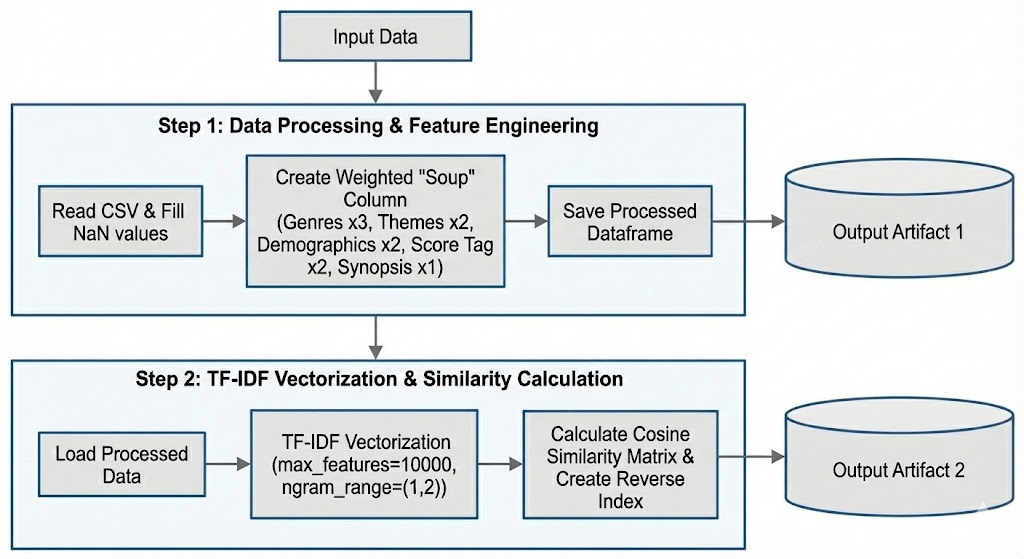

### Evaluating
[Evaluating Recommendation Systems](https://www.researchgate.net/publication/226264572_Evaluating_Recommendation_Systems)